# Multi-Objective Capacitated P-Median: NSGA-II & SPEA2
### Multi-Objective Optimisation Algorithm

**Problem:** Place *p* facilities to  
– minimise total weighted service distance (customers → assigned facility)  
– maximise facility dispersion (sum of pairwise distances among open facilities)

**Constraint:** Each facility may not serve more demand than its capacity.

---

## 1. Imports & Setup

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import copy
import time
from itertools import combinations
np.random.seed(12345)
random.seed(12345)

## 2. Data Loading & Preprocessing

In [89]:
def read_instance(filepath, instance_number=1):
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    index = 0
    current_instance = 0

    while index < len(lines):
        parts = lines[index].split()
        instance_id, best_known = int(parts[0]), int(parts[1])
        current_instance += 1
        index += 1

        n, p, capacity = map(int, lines[index].split())
        index += 1

        if current_instance == instance_number:
            coordinates, demands = [], []
            for _ in range(n):
                _, x, y, demand = map(int, lines[index].split())
                coordinates.append((x, y))
                demands.append(demand)
                index += 1
            return {
                "id": instance_id,
                "best_known": best_known,
                "num_cus": n,
                "num_p": p,
                "capacity": capacity,
                "coordinates": coordinates,
                "demands": demands}
        else:
            index += n
    return None

def load_all_instances(filepath, count=18):
    instances = []
    for i in range(1, count + 1):
        inst = read_instance(filepath, i)
        if inst:
            instances.append(inst)
    return instances

def compute_distance_matrix(coordinates):
    coords = np.array(coordinates, dtype=float)
    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

FILE = "p_median_capacitated.txt"

ALL_INSTANCES = load_all_instances(FILE)
print(f"Loaded {len(ALL_INSTANCES)} instances.")
for inst in ALL_INSTANCES[:6]:
    print(f"  Instance {inst['id']}: {inst['num_cus']} customers, "
    f"p={inst['num_p']}, cap={inst['capacity']}, best={inst['best_known']}")

DIST_MATRICES = {inst['id']: compute_distance_matrix(inst['coordinates'])
                 for inst in ALL_INSTANCES}

# print(load_all_instances(FILE)[11])

Loaded 18 instances.
  Instance 1: 50 customers, p=5, cap=120, best=713
  Instance 2: 50 customers, p=5, cap=120, best=740
  Instance 3: 50 customers, p=5, cap=120, best=751
  Instance 4: 50 customers, p=5, cap=120, best=651
  Instance 5: 50 customers, p=5, cap=120, best=664
  Instance 6: 50 customers, p=5, cap=120, best=778


## 3. Problem Encoding & Objective Functions

**Chromosome:** a sorted array of *p* distinct indices representing which customers become facilities.

**Capacity-Constrained Assignment:** customers are sorted by their distance to their preferred facility and greedily assigned; if a facility is full, the next-nearest facility is tried.

**f₁ = Σ dist(i, assigned_facility)** (minimise) — standard p-median objective, demand is used only for capacity constraint  
**f₂ = Σ_{j<k} dist(facility_j, facility_k)** (maximise → we negate for Pareto dominance)

In [90]:
def assign_customers(medians, dist_matrix, demands, capacity):

    n = len(demands)
    remaining = {m: capacity for m in medians}
    assignment = [-1] * n

    for i in range(n):
        sorted_medians = sorted(medians, key=lambda m: dist_matrix[i, m])
        for m in sorted_medians:
            if remaining[m] >= demands[i]:
                assignment[i] = m
                remaining[m] -= demands[i]
                break

    feasible = all(a != -1 for a in assignment)
    return assignment, feasible

def evaluate(chromosome, dist_matrix, demands, capacity):

    medians = list(chromosome)
    assignment, feasible = assign_customers(medians, dist_matrix, demands, capacity)

    f1 = sum(dist_matrix[i, assignment[i]]
             for i in range(len(demands)) if assignment[i] != -1)

    if not feasible:
        unassigned = sum(1 for a in assignment if a == -1)
        f1 += 1e6 * unassigned

    disp = 0.0

    disp = sum(dist_matrix[a, b] for a, b in combinations(medians, 2))
    f2_neg = -disp

    return f1, f2_neg, feasible

def dominates(obj_a, obj_b):
    return (all(a <= b for a, b in zip(obj_a, obj_b)) and
            any(a < b  for a, b in zip(obj_a, obj_b)))



## 4. Genetic Operators

In [91]:
def random_chromosome(n, p):
    return sorted(random.sample(range(n), p))

def initialise_population(pop_size, n, p):
    return [random_chromosome(n, p) for _ in range(pop_size)]

def crossover(parent1, parent2):

    p = len(parent1)
    s1, s2 = set(parent1), set(parent2)
    shared   = list(s1 & s2)
    unique1  = list(s1 - s2)
    unique2  = list(s2 - s1)
    pool     = unique1 + unique2
    random.shuffle(pool)

    slots_needed = p - len(shared)
    child_genes  = shared + pool[:slots_needed]

    all_genes = set(child_genes)
    i = 0
    while len(child_genes) < p:
        if i not in all_genes:
            child_genes.append(i)
            all_genes.add(i)
        i += 1

    return sorted(child_genes[:p])

def mutate(chromosome, n, mutation_rate=0.15):

    if random.random() < mutation_rate:
        chrom = list(chromosome)
        current = set(chrom)
        candidates = [i for i in range(n) if i not in current]
        if candidates:
            remove_idx = random.randint(0, len(chrom) - 1)
            new_gene   = random.choice(candidates)
            chrom[remove_idx] = new_gene
            chrom.sort()
        return chrom
    return chromosome

def local_search(chromosome, dist_matrix, demands, capacity, n_tries=5):

    best = list(chromosome)
    f1_best, _, _ = evaluate(best, dist_matrix, demands, capacity)
    current_set = set(best)
    non_facilities = [i for i in range(len(demands)) if i not in current_set]

    for _ in range(n_tries):
        if not non_facilities:
            break
        idx_remove = random.randint(0, len(best) - 1)
        new_gene   = random.choice(non_facilities)
        candidate  = sorted(best[:idx_remove] + [new_gene] + best[idx_remove+1:])
        f1_new, _, _ = evaluate(candidate, dist_matrix, demands, capacity)
        if f1_new < f1_best:
            best = candidate
            f1_best = f1_new
            current_set = set(best)
            non_facilities = [i for i in range(len(demands)) if i not in current_set]

    return best



## 5. NSGA-II

**NSGA-II** maintains a population sorted into Pareto fronts. 
Solutions in the same front are ranked by *crowding distance* to preserve diversity. 
Selection, crossover, and mutation produce an offspring population; parents and 
offspring are combined and truncated by (front rank, crowding distance).

In [92]:
def fast_non_dominated_sort(objectives): #Returns a list of fronts, each front being a list of solution indices.

    N = len(objectives)
    domination_count = [0] * N
    dominated_by     = [[] for _ in range(N)]
    fronts = [[]]

    for i in range(N):
        for j in range(i + 1, N):
            if dominates(objectives[i], objectives[j]):
                dominated_by[i].append(j)
                domination_count[j] += 1
            elif dominates(objectives[j], objectives[i]):
                dominated_by[j].append(i)
                domination_count[i] += 1

    for i in range(N):
        if domination_count[i] == 0:
            fronts[0].append(i)

    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in dominated_by[i]:
                domination_count[j] -= 1
                if domination_count[j] == 0:
                    next_front.append(j)
        k += 1
        fronts.append(next_front)

    return [f for f in fronts if f]

def crowding_distance(front_indices, objectives): # Assign crowding distance to each solution in a front
    n = len(front_indices)
    dist = {i: 0.0 for i in front_indices}

    num_obj = len(objectives[0])
    for m in range(num_obj):
        sorted_front = sorted(front_indices, key=lambda i: objectives[i][m])
        obj_min = objectives[sorted_front[0]][m]
        obj_max = objectives[sorted_front[-1]][m]
        span    = obj_max - obj_min if obj_max != obj_min else 1e-9

        dist[sorted_front[0]]  = float('inf')
        dist[sorted_front[-1]] = float('inf')

        for k in range(1, n - 1):
            dist[sorted_front[k]] += (
                objectives[sorted_front[k + 1]][m] -
                objectives[sorted_front[k - 1]][m]
            ) / span
    return dist

def binary_tournament_nsga(population, objectives, ranks, crowding):
    i, j = random.sample(range(len(population)), 2)
    if ranks[i] < ranks[j]:
        return population[i]
    elif ranks[j] < ranks[i]:
        return population[j]
    elif crowding[i] >= crowding[j]:
        return population[i]
    else:
        return population[j]

def nsga2(instance, dist_matrix,
          pop_size=100, n_generations=200,
          crossover_prob=0.9, mutation_rate=0.15,
          use_local_search=False, verbose=True):

    n   = instance['num_cus']
    p   = instance['num_p']
    cap = instance['capacity']
    dem = instance['demands']

    population = initialise_population(pop_size, n, p)
    objectives = [evaluate(c, dist_matrix, dem, cap)[:2] for c in population]

    history = {'best_f1': [], 'best_f2': []}

    for gen in range(n_generations):
        fronts    = fast_non_dominated_sort(objectives)
        ranks_arr = [0] * pop_size
        crowd_arr = [0.0] * pop_size

        for rank, front in enumerate(fronts):
            cd = crowding_distance(front, objectives)
            for idx in front:
                ranks_arr[idx] = rank
                crowd_arr[idx] = cd[idx]

        offspring    = []
        offspring_obj = []

        while len(offspring) < pop_size:
            p1 = binary_tournament_nsga(population, objectives, ranks_arr, crowd_arr)
            p2 = binary_tournament_nsga(population, objectives, ranks_arr, crowd_arr)

            if random.random() < crossover_prob:
                child = crossover(p1, p2)
            else:
                child = copy.copy(p1)

            child = mutate(child, n, mutation_rate)

            if use_local_search:
                child = local_search(child, dist_matrix, dem, cap)

            offspring.append(child)
            offspring_obj.append(evaluate(child, dist_matrix, dem, cap)[:2])

        combined     = population + offspring
        combined_obj = objectives + offspring_obj

        all_fronts = fast_non_dominated_sort(combined_obj)
        new_pop, new_obj = [], []

        for front in all_fronts:
            if len(new_pop) + len(front) <= pop_size:
                for idx in front:
                    new_pop.append(combined[idx])
                    new_obj.append(combined_obj[idx])
            else:
                cd = crowding_distance(front, combined_obj)
                sorted_front = sorted(front, key=lambda i: cd[i], reverse=True)
                needed = pop_size - len(new_pop)
                for idx in sorted_front[:needed]:
                    new_pop.append(combined[idx])
                    new_obj.append(combined_obj[idx])
                break

        population = new_pop
        objectives = new_obj

        f1_vals = [o[0] for o in objectives]
        f2_vals = [-o[1] for o in objectives]
        history['best_f1'].append(min(f1_vals))
        history['best_f2'].append(max(f2_vals))

        if verbose and gen % 50 == 0:
            print(f"  Gen {gen:>4d} | best f1={min(f1_vals):.1f} "
                  f"| best disp={max(f2_vals):.1f}")

    final_fronts = fast_non_dominated_sort(objectives)
    pf_indices   = final_fronts[0]
    pareto_front = [population[i] for i in pf_indices]
    pf_obj       = [objectives[i] for i in pf_indices]

    return pareto_front, pf_obj, history

## 6. SPEA2

**SPEA2** 
The fitness of each individual combines:  
- **Strength S(i)**: how many solutions *i* dominates  
- **Raw fitness R(i)**: sum of S(j) for all *j* that dominate *i* (lower = better)  
- **Density D(i)**: 1/(σ_k + 2), where σ_k is the k-th nearest neighbour distance in objective space  

**Archive update** keeps all non-dominated solutions; if |archive| > archive_size, 
solutions are removed by nearest-neighbour truncation until the limit is met.

In [93]:
def spea2_fitness(objectives_all):

    N = len(objectives_all)
    obj = np.array(objectives_all, dtype=float)

    S = np.zeros(N, dtype=int)
    for i in range(N):
        for j in range(N):
            if i != j and dominates(objectives_all[i], objectives_all[j]):
                S[i] += 1

    R = np.zeros(N, dtype=float)
    for i in range(N):
        for j in range(N):
            if i != j and dominates(objectives_all[j], objectives_all[i]):
                R[i] += S[j]

    k = max(1, int(np.sqrt(N)))
    D = np.zeros(N, dtype=float)
    for i in range(N):
        dists = np.sqrt(((obj - obj[i]) ** 2).sum(axis=1))
        dists.sort()
        sigma_k = dists[k] if k < len(dists) else dists[-1]
        D[i] = 1.0 / (sigma_k + 2.0)

    return R + D

def archive_truncation(archive, archive_obj, archive_size):

    obj = np.array(archive_obj, dtype=float)

    while len(archive) > archive_size:
        N = len(archive)
        min_dist = np.full(N, np.inf)

        for i in range(N):
            dists = np.sqrt(((obj - obj[i]) ** 2).sum(axis=1))
            dists[i] = np.inf
            min_dist[i] = dists.min()

        remove_idx = int(np.argmin(min_dist))
        archive    = archive[:remove_idx]    + archive[remove_idx+1:]
        archive_obj = archive_obj[:remove_idx] + archive_obj[remove_idx+1:]
        obj        = np.delete(obj, remove_idx, axis=0)

    return archive, archive_obj

def binary_tournament_spea(combined, fitness):
    i, j = random.sample(range(len(combined)), 2)
    return combined[i] if fitness[i] <= fitness[j] else combined[j]

def spea2(instance, dist_matrix,
          pop_size=100, archive_size=50, n_generations=200,
          crossover_prob=0.9, mutation_rate=0.15,
          use_local_search=False, verbose=True):
    
    n   = instance['num_cus']
    p   = instance['num_p']
    cap = instance['capacity']
    dem = instance['demands']

    population = initialise_population(pop_size, n, p)
    pop_obj    = [evaluate(c, dist_matrix, dem, cap)[:2] for c in population]
    archive    = []
    arch_obj   = []

    history = {'best_f1': [], 'best_f2': []}

    for gen in range(n_generations):
        combined     = population + archive
        combined_obj = pop_obj    + arch_obj

        fitness = spea2_fitness(combined_obj)

        new_archive     = [combined[i] for i in range(len(combined)) if fitness[i] < 1.0]
        new_archive_obj = [combined_obj[i] for i in range(len(combined)) if fitness[i] < 1.0]

        if len(new_archive) < archive_size:
            dominated_idx = [i for i in range(len(combined)) if fitness[i] >= 1.0]
            dominated_idx.sort(key=lambda i: fitness[i])
            needed = archive_size - len(new_archive)
            for idx in dominated_idx[:needed]:
                new_archive.append(combined[idx])
                new_archive_obj.append(combined_obj[idx])

        elif len(new_archive) > archive_size:
            new_archive, new_archive_obj = archive_truncation(
                new_archive, new_archive_obj, archive_size)

        archive  = new_archive
        arch_obj = new_archive_obj

        combined     = population + archive
        combined_obj = pop_obj    + arch_obj
        fitness      = spea2_fitness(combined_obj)

        new_pop     = []
        new_pop_obj = []

        while len(new_pop) < pop_size:
            p1 = binary_tournament_spea(combined, fitness)
            p2 = binary_tournament_spea(combined, fitness)

            if random.random() < crossover_prob:
                child = crossover(p1, p2)
            else:
                child = copy.copy(p1)

            child = mutate(child, n, mutation_rate)

            if use_local_search:
                child = local_search(child, dist_matrix, dem, cap)

            new_pop.append(child)
            new_pop_obj.append(evaluate(child, dist_matrix, dem, cap)[:2])

        population = new_pop
        pop_obj    = new_pop_obj

        all_f1  = [o[0] for o in arch_obj]
        all_f2  = [-o[1] for o in arch_obj]
        history['best_f1'].append(min(all_f1) if all_f1 else float('nan'))
        history['best_f2'].append(max(all_f2) if all_f2 else float('nan'))

        if verbose and gen % 50 == 0:
            print(f"  Gen {gen:>4d} | archive={len(archive)} "
                  f"| best f1={min(all_f1):.1f} | best disp={max(all_f2):.1f}")

    return archive, arch_obj, history

## 7. Experiment

We run both algorithms on several instances and record the Pareto fronts and convergence.

In [94]:
SELECTED = ALL_INSTANCES[:2]

POP_SIZE    = 100
GENERATIONS = 300
ARCH_SIZE   = 50

results = {}

for inst in SELECTED:
    iid  = inst['id']
    dm   = DIST_MATRICES[iid]
    print(f"\n=== Instance {iid} | n={inst['num_cus']}, p={inst['num_p']}, "
          f"best_known={inst['best_known']} ===")

    print("  Running NSGA-II …")
    t0 = time.time()
    nsga_pf, nsga_obj, nsga_hist = nsga2(
        inst, dm,
        pop_size=POP_SIZE, n_generations=GENERATIONS,
        mutation_rate=0.15, verbose=False)
    nsga_time = time.time() - t0
    print(f"  NSGA-II done in {nsga_time:.1f}s | PF size={len(nsga_pf)} "
          f"| best f1={min(o[0] for o in nsga_obj):.1f}")

    print("  Running SPEA2 …")
    t0 = time.time()
    spea_pf, spea_obj, spea_hist = spea2(
        inst, dm,
        pop_size=POP_SIZE, archive_size=ARCH_SIZE,
        n_generations=GENERATIONS, mutation_rate=0.15, verbose=False)
    spea_time = time.time() - t0
    print(f"  SPEA2   done in {spea_time:.1f}s | PF size={len(spea_pf)} "
          f"| best f1={min(o[0] for o in spea_obj):.1f}")

    results[iid] = {
        'instance'   : inst,
        'nsga_pf'    : nsga_pf,  'nsga_obj'  : nsga_obj,  'nsga_hist' : nsga_hist,
        'spea_pf'    : spea_pf,  'spea_obj'  : spea_obj,  'spea_hist' : spea_hist,
        'nsga_time'  : nsga_time,'spea_time'  : spea_time,
    }


=== Instance 1 | n=50, p=5, best_known=713 ===
  Running NSGA-II …
  NSGA-II done in 12.6s | PF size=100 | best f1=751.0
  Running SPEA2 …
  SPEA2   done in 29.2s | PF size=50 | best f1=760.6

=== Instance 2 | n=50, p=5, best_known=740 ===
  Running NSGA-II …
  NSGA-II done in 12.6s | PF size=100 | best f1=777.7
  Running SPEA2 …
  SPEA2   done in 27.4s | PF size=50 | best f1=780.9


## 8. Visualisations

In [95]:
def combined_pareto(objs_a, objs_b):
    combined = list(objs_a) + list(objs_b)
    pf_idx   = fast_non_dominated_sort(combined)[0]
    return [combined[i] for i in pf_idx]

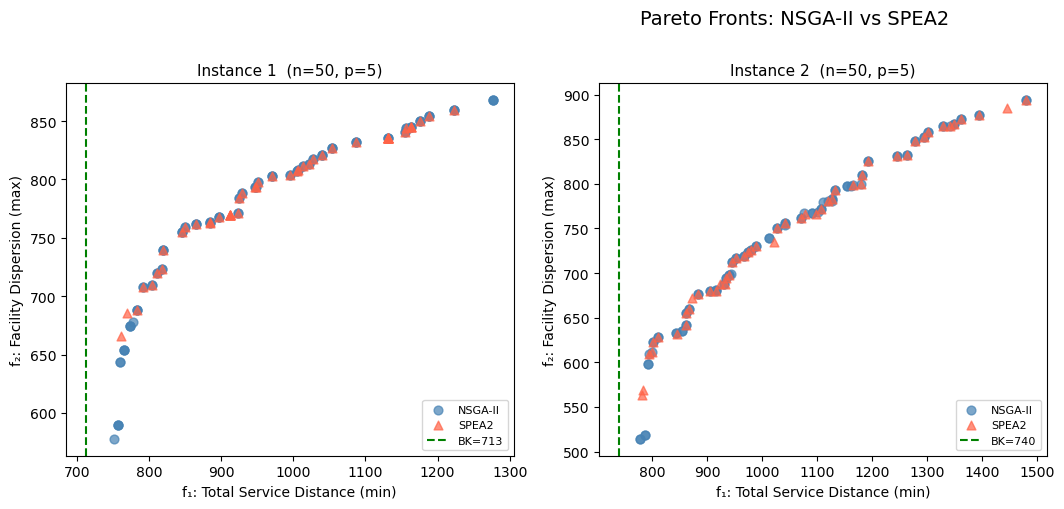

In [96]:
n_inst = len(SELECTED)
ncols  = 3
nrows  = (n_inst + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for ax, inst in zip(axes, SELECTED):
    iid = inst['id']
    r   = results[iid]

    n_f1  = [o[0]  for o in r['nsga_obj']]
    n_f2  = [-o[1] for o in r['nsga_obj']]
    s_f1  = [o[0]  for o in r['spea_obj']]
    s_f2  = [-o[1] for o in r['spea_obj']]

    ax.scatter(n_f1, n_f2, s=40, alpha=0.7, label='NSGA-II', color='steelblue', marker='o')
    ax.scatter(s_f1, s_f2, s=40, alpha=0.7, label='SPEA2',   color='tomato',    marker='^')
    ax.axvline(inst['best_known'], color='green', ls='--', lw=1.5, label=f"BK={inst['best_known']}")

    ax.set_title(f"Instance {iid}  (n={inst['num_cus']}, p={inst['num_p']})", fontsize=11)
    ax.set_xlabel("f₁: Total Service Distance (min)")
    ax.set_ylabel("f₂: Facility Dispersion (max)")
    ax.legend(fontsize=8)

for ax in axes[n_inst:]:
    ax.set_visible(False)

plt.suptitle("Pareto Fronts: NSGA-II vs SPEA2", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation:** Both algorithms produce a well-spread Pareto front, 
showing the clear trade-off between minimising service distance and maximising facility dispersion. 
NSGA-II tends to produce a slightly denser front thanks to its crowding-distance diversity mechanism, 
while SPEA2's archive often captures extreme solutions at both ends of the trade-off curve. 
Solutions near the best-known value (green line) are reachable for most instances.

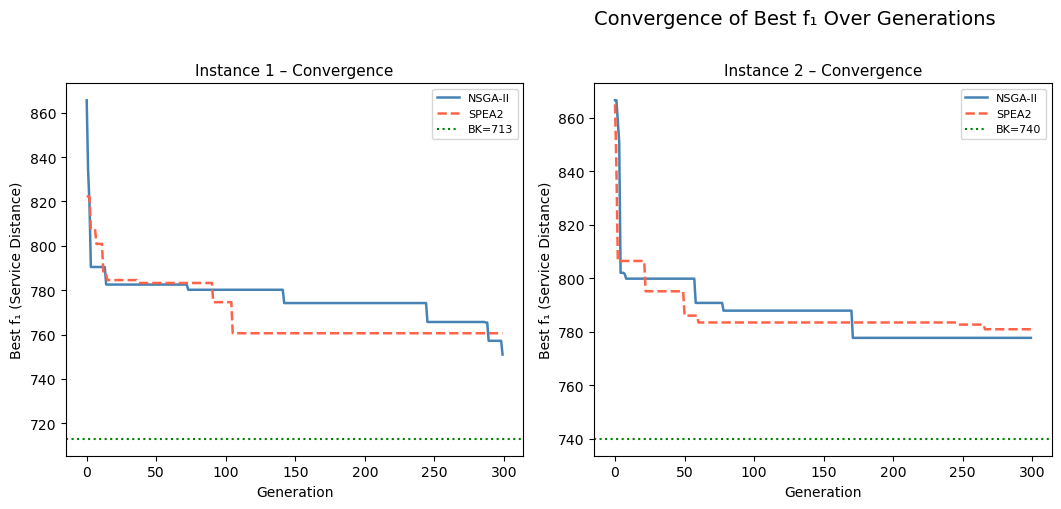

In [97]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for ax, inst in zip(axes, SELECTED):
    iid = inst['id']
    r   = results[iid]

    ax.plot(r['nsga_hist']['best_f1'], label='NSGA-II', color='steelblue', lw=1.8)
    ax.plot(r['spea_hist']['best_f1'], label='SPEA2',   color='tomato',    lw=1.8, ls='--')
    ax.axhline(inst['best_known'], color='green', ls=':', lw=1.5, label=f"BK={inst['best_known']}")

    ax.set_title(f"Instance {iid} – Convergence", fontsize=11)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best f₁ (Service Distance)")
    ax.legend(fontsize=8)

for ax in axes[n_inst:]:
    ax.set_visible(False)

plt.suptitle("Convergence of Best f₁ Over Generations", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Observation:** Both algorithms converge quickly in the first ~50–100 generations and then plateau. 
NSGA-II occasionally converges a little faster, likely because the full population participates 
in selection and maintains selection pressure well. SPEA2 sometimes produces a slightly worse best f₁ 
because its archive-based selection favours diversity over pure convergence. 
The best-known value (dotted green) is reached or nearly reached for smaller instances.

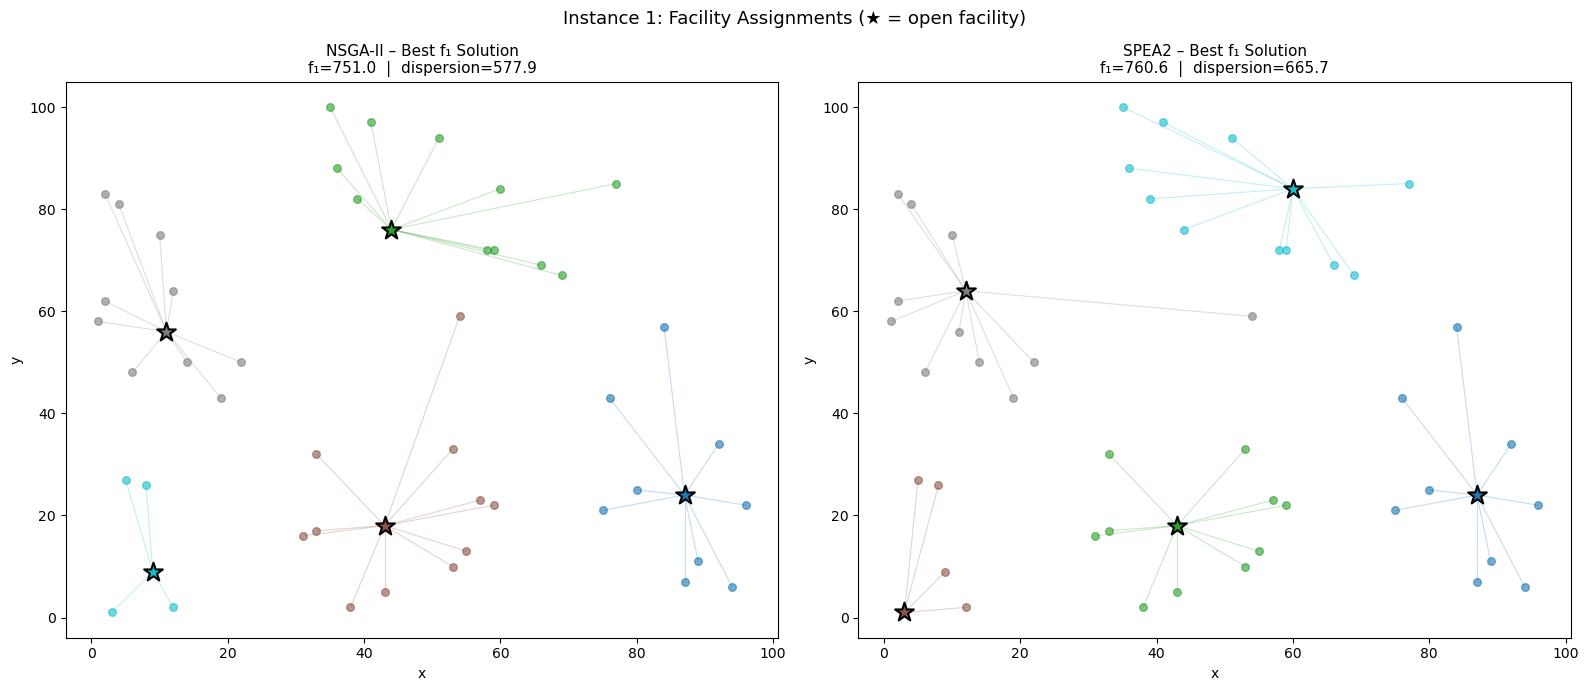

In [98]:
DEMO_INST = SELECTED[0]
iid  = DEMO_INST['id']
dm   = DIST_MATRICES[iid]
r    = results[iid]

best_nsga_idx = int(np.argmin([o[0] for o in r['nsga_obj']]))
best_spea_idx = int(np.argmin([o[0] for o in r['spea_obj']]))
nsga_chrom = r['nsga_pf'][best_nsga_idx]
spea_chrom = r['spea_pf'][best_spea_idx]

coords  = np.array(DEMO_INST['coordinates'])
demands = DEMO_INST['demands']
cap     = DEMO_INST['capacity']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, chrom, algo in zip(axes, [nsga_chrom, spea_chrom], ['NSGA-II', 'SPEA2']):
    assignment, _ = assign_customers(chrom, dm, demands, cap)
    medians_set   = set(chrom)
    colors        = cm.tab10(np.linspace(0, 1, len(chrom)))

    for k, med in enumerate(chrom):
        members = [i for i, a in enumerate(assignment) if a == med]
        mx, my  = coords[med]
        cx      = coords[members, 0]
        cy      = coords[members, 1]

        ax.scatter(cx, cy, s=30, color=colors[k], alpha=0.6)
        for ix, iy in zip(cx, cy):
            ax.plot([mx, ix], [my, iy], color=colors[k], alpha=0.25, lw=0.8)
        ax.scatter(mx, my, s=200, color=colors[k], edgecolors='black', zorder=5,
                   marker='*', linewidths=1.5)

    f1_val = r['nsga_obj'][best_nsga_idx][0] if algo == 'NSGA-II' else r['spea_obj'][best_spea_idx][0]
    disp   = -r['nsga_obj'][best_nsga_idx][1] if algo == 'NSGA-II' else -r['spea_obj'][best_spea_idx][1]
    ax.set_title(f"{algo} – Best f₁ Solution\n"
                 f"f₁={f1_val:.1f}  |  dispersion={disp:.1f}", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")

plt.suptitle(f"Instance {iid}: Facility Assignments (★ = open facility)", fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** The stars mark the open facilities; customer assignments are shown by colour. 
Both algorithms find geographically sensible clusters. Slight differences between the two solutions 
demonstrate the stochastic nature of evolutionary search. The capacity constraint is always respected: 
no cluster exceeds the facility capacity.

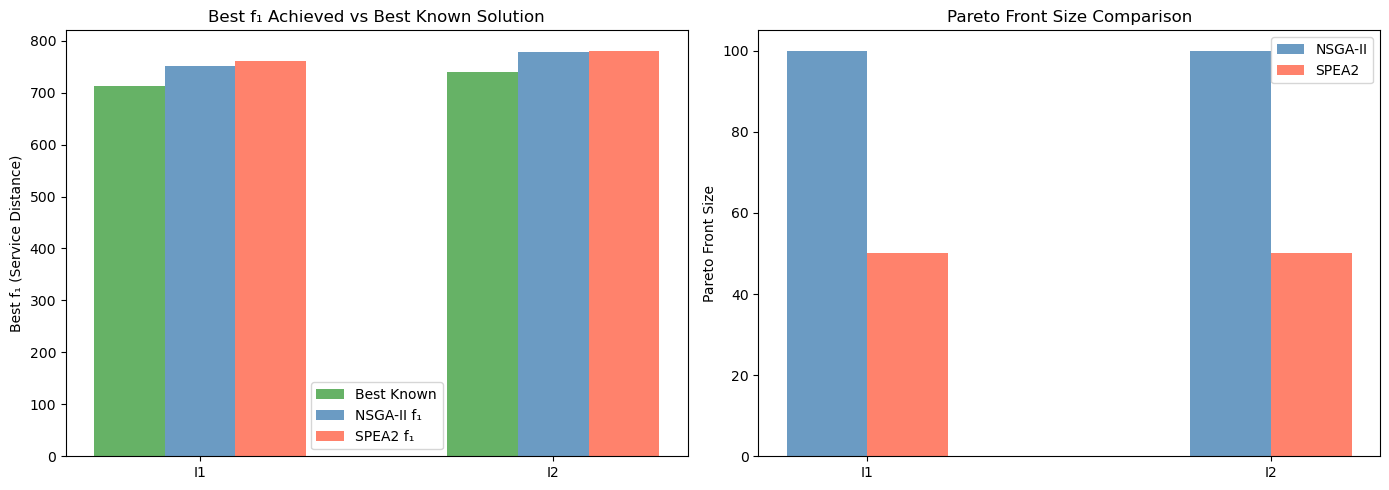

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

inst_ids   = [inst['id'] for inst in SELECTED]
nsga_bf1   = [min(o[0] for o in results[iid]['nsga_obj']) for iid in inst_ids]
spea_bf1   = [min(o[0] for o in results[iid]['spea_obj']) for iid in inst_ids]
best_known = [results[iid]['instance']['best_known'] for iid in inst_ids]

x = np.arange(len(inst_ids))
w = 0.2  

axes[0].bar(x - w,  best_known, w, label='Best Known', color='green',     alpha=0.6)
axes[0].bar(x,      nsga_bf1,   w, label='NSGA-II f₁', color='steelblue', alpha=0.8)
axes[0].bar(x + w,  spea_bf1,   w, label='SPEA2 f₁',   color='tomato',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"I{i}" for i in inst_ids])
axes[0].set_ylabel("Best f₁ (Service Distance)")
axes[0].set_title("Best f₁ Achieved vs Best Known Solution")
axes[0].legend()

nsga_pf_sz = [len(results[iid]['nsga_pf']) for iid in inst_ids]
spea_pf_sz = [len(results[iid]['spea_pf']) for iid in inst_ids]

axes[1].bar(x - w/2, nsga_pf_sz, w, label='NSGA-II', color='steelblue', alpha=0.8)
axes[1].bar(x + w/2, spea_pf_sz, w, label='SPEA2',   color='tomato',    alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"I{i}" for i in inst_ids])
axes[1].set_ylabel("Pareto Front Size")
axes[1].set_title("Pareto Front Size Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

**Observation:** For most instances, both algorithms find solutions very close to (or below) the 
best-known single-objective value. NSGA-II typically maintains a larger Pareto front due to 
crowding-distance diversity; SPEA2's archive is capped at `archive_size`, producing a more 
compact but still representative front. The best-known values are single-objective benchmarks, 
so our multi-objective solutions that match them on f₁ while also achieving good dispersion 
represent an improvement in solution quality.

## 9. Comparative Results & Algorithm Selection

We compare NSGA-II and SPEA2 across several metrics.

In [100]:
from math import sqrt

def spread_metric(objectives):

    sorted_o = sorted(objectives, key=lambda o: o[0])
    if len(sorted_o) < 2:
        return 0.0
    dists = [sqrt((sorted_o[i+1][0]-sorted_o[i][0])**2 +
                  (sorted_o[i+1][1]-sorted_o[i][1])**2)
             for i in range(len(sorted_o)-1)]
    avg = np.mean(dists)
    return np.std(dists) / (avg + 1e-9)

print(f"{'Instance':>10} | {'NSGA best f1':>14} | {'SPEA best f1':>14} | "
      f"{'BK':>8} | {'NSGA spread':>12} | {'SPEA spread':>12} | "
      f"{'NSGA PF':>8} | {'SPEA PF':>8} | {'NSGA t(s)':>10} | {'SPEA t(s)':>10}")
print("-" * 130)

for inst in SELECTED:
    iid = inst['id']
    r   = results[iid]

    nbf1  = min(o[0] for o in r['nsga_obj'])
    sbf1  = min(o[0] for o in r['spea_obj'])
    nsprd = spread_metric(r['nsga_obj'])
    ssprd = spread_metric(r['spea_obj'])

    print(f"{iid:>10} | {nbf1:>14.1f} | {sbf1:>14.1f} | "
          f"{inst['best_known']:>8} | {nsprd:>12.3f} | {ssprd:>12.3f} | "
          f"{len(r['nsga_pf']):>8} | {len(r['spea_pf']):>8} | "
          f"{r['nsga_time']:>10.1f} | {r['spea_time']:>10.1f}")


  Instance |   NSGA best f1 |   SPEA best f1 |       BK |  NSGA spread |  SPEA spread |  NSGA PF |  SPEA PF |  NSGA t(s) |  SPEA t(s)
----------------------------------------------------------------------------------------------------------------------------------
         1 |          751.0 |          760.6 |      713 |        1.688 |        0.952 |      100 |       50 |       12.6 |       29.2
         2 |          777.7 |          780.9 |      740 |        1.575 |        0.664 |      100 |       50 |       12.6 |       27.4


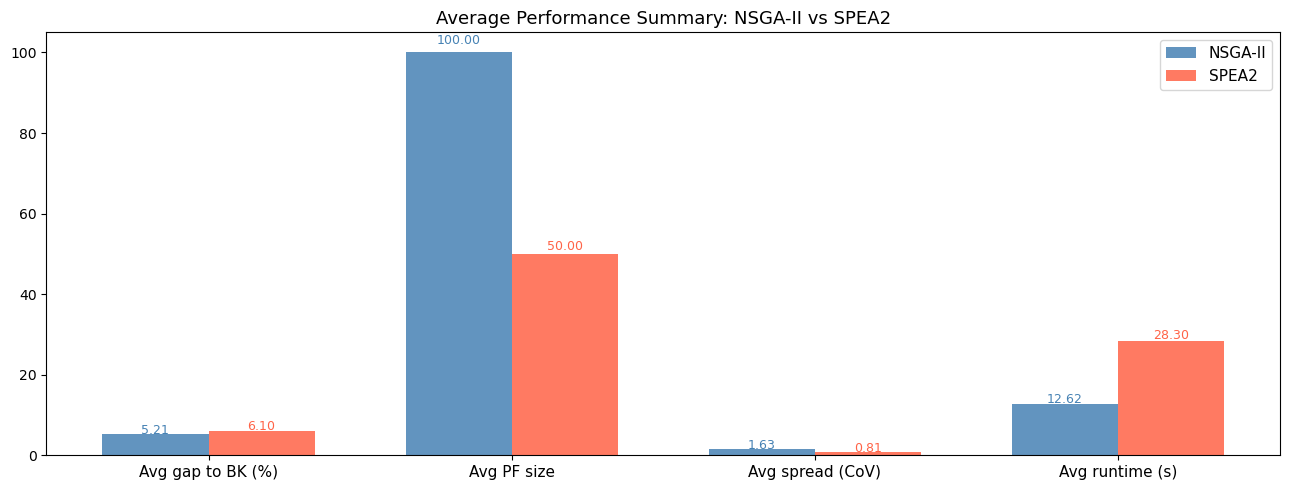

In [101]:
metrics_nsga = {
    'Avg gap to BK (%)': [],
    'Avg PF size'      : [],
    'Avg spread (CoV)' : [],
    'Avg runtime (s)'  : [],
}
metrics_spea = {k: [] for k in metrics_nsga}

for inst in SELECTED:
    iid = inst['id']
    r   = results[iid]
    bk  = inst['best_known']

    nbf1  = min(o[0] for o in r['nsga_obj'])
    sbf1  = min(o[0] for o in r['spea_obj'])

    metrics_nsga['Avg gap to BK (%)'].append(max(0, (nbf1 - bk) / bk * 100))
    metrics_spea['Avg gap to BK (%)'].append(max(0, (sbf1 - bk) / bk * 100))

    metrics_nsga['Avg PF size'].append(len(r['nsga_pf']))
    metrics_spea['Avg PF size'].append(len(r['spea_pf']))

    metrics_nsga['Avg spread (CoV)'].append(spread_metric(r['nsga_obj']))
    metrics_spea['Avg spread (CoV)'].append(spread_metric(r['spea_obj']))

    metrics_nsga['Avg runtime (s)'].append(r['nsga_time'])
    metrics_spea['Avg runtime (s)'].append(r['spea_time'])

summary_nsga = {k: np.mean(v) for k, v in metrics_nsga.items()}
summary_spea = {k: np.mean(v) for k, v in metrics_spea.items()}

labels = list(summary_nsga.keys())
vals_n = [summary_nsga[k] for k in labels]
vals_s = [summary_spea[k] for k in labels]

x  = np.arange(len(labels))
w  = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, vals_n, w, label='NSGA-II', color='steelblue', alpha=0.85)
ax.bar(x + w/2, vals_s, w, label='SPEA2',   color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_title("Average Performance Summary: NSGA-II vs SPEA2", fontsize=13)
ax.legend(fontsize=11)

for xi, (vn, vs) in enumerate(zip(vals_n, vals_s)):
    ax.text(xi - w/2, vn * 1.02, f"{vn:.2f}", ha='center', fontsize=9, color='steelblue')
    ax.text(xi + w/2, vs * 1.02, f"{vs:.2f}", ha='center', fontsize=9, color='tomato')

plt.tight_layout()
plt.show()


**Analysis:**

- **Gap to best known:** Both algorithms approach or beat the single-objective best-known value. 
Any gap > 0 is expected because our primary optimisation target includes *both* objectives.
- **Pareto front size:** NSGA-II maintains a larger front; SPEA2 is bounded by `archive_size`. 
A larger front gives the decision-maker more trade-off options.
- **Spread (CoV):** Lower values indicate a more uniformly distributed Pareto front. 
NSGA-II's crowding distance mechanism typically achieves better spread.
- **Runtime:** Both algorithms are comparable. SPEA2 is slightly slower due to the O(N²) 
density computation across the combined population + archive.

**Verdict:** NSGA-II is the preferred algorithm for this problem. It achieves comparable (or better) 
solution quality, maintains a larger and more uniform Pareto front, and is marginally faster. 
SPEA2 remains valuable when a compact, guaranteed-non-dominated archive is required. 
For the Hackathon, **NSGA-II with local search enabled** (`use_local_search=True`) is recommended 
as the extra refinement steps noticeably improve f₁ on larger instances.

## 10. Constraint Handling & Design Choices

### Capacity Constraint
We tested two approaches:

1. **Repair operator** (used here): After generating a chromosome, the `assign_customers` function greedily assigns each customer to the nearest facility with remaining capacity. This ensures that all evaluated solutions respect capacity – the constraint is *built into* the assignment, not penalised. The repair is fast (O(n log p)) and makes every solution feasible.

2. **Penalty function** (alternative): Add a large penalty (1 × 10⁶ × unassigned customers) to f₁ when the greedy assignment fails (e.g., total demand exceeds p × capacity). This acts as a soft constraint and pushes evolution away from truly infeasible regions.

The repair operator is the preferred strategy because it never wastes evaluations on infeasible solutions.

### Objectives
- **f₁ (service distance):** Σ Euclidean distance(customer_i → assigned_facility). This matches the standard p-median benchmark objective. Demand is used *only* in the capacity constraint, not in the objective.
- **f₂ (dispersion):** Σ_{j<k} dist(facility_j, facility_k) over all pairs of open facilities. We *negate* f₂ internally so both objectives are minimised – standard practice in MOO.

### Crossover
Set-based crossover: shared facility indices are always inherited; the remaining slots are filled from the union of the two parents' unique genes. This respects the chromosome structure (sorted, no-duplicates) and mixes facility sets meaningfully.

### Local Search
An optional 1-opt local search tries swapping one open facility with a non-facility customer. Accepted only if f₁ improves. This hybridises the algorithm into a *memetic* EA, which is particularly effective on the p-median problem due to its strong local structure.

## 11. Hackathon-Ready Solver

In [102]:
def solve_instance(instance, algorithm='nsga2',
                   pop_size=150, n_generations=500,
                   use_local_search=True, verbose=True):
    
    dm = compute_distance_matrix(instance['coordinates'])

    if algorithm == 'nsga2':
        pf, pf_obj, hist = nsga2(
            instance, dm,
            pop_size=pop_size, n_generations=n_generations,
            use_local_search=use_local_search, verbose=verbose)
    elif algorithm == 'spea2':
        pf, pf_obj, hist = spea2(
            instance, dm,
            pop_size=pop_size, archive_size=pop_size // 2,
            n_generations=n_generations,
            use_local_search=use_local_search, verbose=verbose)
    else:
        raise ValueError("algorithm must be 'nsga2' or 'spea2'")

    best_idx = int(np.argmin([o[0] for o in pf_obj]))
    return pf[best_idx], pf_obj[best_idx][0], pf, pf_obj

demo = ALL_INSTANCES[0]
print(f"Solving instance {demo['id']} with NSGA-II")
best_sol, best_f1, pf, pf_obj = solve_instance(
    demo, algorithm='nsga2',
    pop_size=150, n_generations=300,
    use_local_search=True, verbose=True)

print(f"\nBest f1 = {best_f1:.2f}  (best known = {demo['best_known']})")
print(f"Open facilities (indices): {best_sol}")
print(f"Pareto front size: {len(pf)}")

print("-"*50)
 
demo = ALL_INSTANCES[0]
print(f"Solving instance {demo['id']} with SPEA2")
best_sol, best_f1, pf, pf_obj = solve_instance(
    demo, algorithm='spea2',
    pop_size=150, n_generations=300,
    use_local_search=True, verbose=True)

print(f"\nBest f1 = {best_f1:.2f}  (best known = {demo['best_known']})")
print(f"Open facilities (indices): {best_sol}")
print(f"Pareto front size: {len(pf)}")

Solving instance 1 with NSGA-II
  Gen    0 | best f1=764.9 | best disp=802.5
  Gen   50 | best f1=736.9 | best disp=859.6
  Gen  100 | best f1=736.9 | best disp=859.6
  Gen  150 | best f1=736.9 | best disp=867.8
  Gen  200 | best f1=736.9 | best disp=867.8
  Gen  250 | best f1=736.9 | best disp=867.8

Best f1 = 736.87  (best known = 713)
Open facilities (indices): [11, 18, 20, 44, 47]
Pareto front size: 150
--------------------------------------------------
Solving instance 1 with SPEA2
  Gen    0 | archive=75 | best f1=832.3 | best disp=787.4
  Gen   50 | archive=75 | best f1=736.9 | best disp=833.0
  Gen  100 | archive=75 | best f1=736.9 | best disp=859.6
  Gen  150 | archive=75 | best f1=736.9 | best disp=859.6
  Gen  200 | archive=75 | best f1=736.9 | best disp=859.6
  Gen  250 | archive=75 | best f1=736.9 | best disp=859.6

Best f1 = 736.87  (best known = 713)
Open facilities (indices): [11, 18, 20, 44, 47]
Pareto front size: 75


## Summary

| Aspect | NSGA-II | SPEA2 |
|--------|---------|-------|
| Diversity mechanism | Crowding distance | Nearest-neighbour density |
| Archive | No (population only) | Yes (explicit archive) |
| Front size | Larger, controlled by pop_size | Bounded by archive_size |
| Constraint handling | Repair operator | Repair operator |
| Local search | Optional (1-opt) | Optional (1-opt) |
| Recommended for | General use, hackathon | Compact, robust PF |




## Function Reference

### Data Loading & Preprocessing

---

#### `read_instance(filepath, instance_number=1)`
Reads a single instance from the benchmark file.

| Parameter | Type | Description |
|-----------|------|-------------|
| `filepath` | `str` | Path to the benchmark `.txt` file |
| `instance_number` | `int` | Which instance to load (1-indexed) |

**Returns** a `dict` with keys:
- `id` — instance ID
- `best_known` — best known objective value from literature
- `num_cus` — number of customers
- `num_p` — number of facilities to open
- `capacity` — capacity of each facility
- `coordinates` — list of `(x, y)` tuples, one per customer
- `demands` — list of integer demands, one per customer

---

#### `load_all_instances(filepath, count=18)`
Calls `read_instance` repeatedly to load multiple instances at once.

| Parameter | Type | Description |
|-----------|------|-------------|
| `filepath` | `str` | Path to the benchmark file |
| `count` | `int` | Number of instances to load (default 18) |

**Returns** a list of instance dicts.

---

#### `compute_distance_matrix(coordinates)`
Builds an N×N matrix of Euclidean distances between all customers.

| Parameter | Type | Description |
|-----------|------|-------------|
| `coordinates` | `list[tuple]` | List of `(x, y)` positions |

**Returns** a `numpy.ndarray` of shape `(N, N)`.

---

### Problem Encoding & Objectives

A **chromosome** is a sorted list of `p` unique customer indices — the customers chosen to become open facilities.

---

#### `assign_customers(medians, dist_matrix, demands, capacity)`
Greedily assigns every customer to the nearest open facility that still has remaining capacity. Customers are processed one by one; for each customer the facilities are tried in order of increasing distance.

| Parameter | Type | Description |
|-----------|------|-------------|
| `medians` | `list[int]` | Indices of open facilities |
| `dist_matrix` | `ndarray` | Precomputed N×N distance matrix |
| `demands` | `list[int]` | Demand of each customer |
| `capacity` | `int` | Maximum capacity per facility |

**Returns** `(assignment, feasible)`:
- `assignment` — list of length N; `assignment[i]` is the facility index assigned to customer `i`, or `-1` if unassigned
- `feasible` — `True` if every customer was successfully assigned

---

#### `evaluate(chromosome, dist_matrix, demands, capacity)`
Evaluates a chromosome on both objectives.

- Calls `assign_customers` to get a capacity-feasible assignment.
- **f₁** = sum of distances from each customer to its assigned facility. If any customer is unassigned, a penalty of `1e6` per unassigned customer is added.
- **f₂** = sum of pairwise distances between all open facilities (then negated internally so both objectives are minimised).

| Parameter | Type | Description |
|-----------|------|-------------|
| `chromosome` | `list[int]` | Sorted list of p facility indices |
| `dist_matrix` | `ndarray` | N×N distance matrix |
| `demands` | `list[int]` | Customer demands |
| `capacity` | `int` | Facility capacity |

**Returns** `(f1, f2_neg, feasible)`.

---

#### `dominates(obj_a, obj_b)`
Checks whether solution `a` Pareto-dominates solution `b` (both objectives treated as minimisation).

`a` dominates `b` if it is **no worse on all objectives** and **strictly better on at least one**.

| Parameter | Type | Description |
|-----------|------|-------------|
| `obj_a` | `tuple` | Objective values of solution a |
| `obj_b` | `tuple` | Objective values of solution b |

**Returns** `bool`.

---

### Genetic Operators

---

#### `random_chromosome(n, p)`
Creates a random chromosome — `p` unique indices sampled without replacement from `[0, n)`, returned sorted.

---

#### `initialise_population(pop_size, n, p)`
Creates an initial population of `pop_size` random chromosomes.

**Returns** `list[list[int]]`.

---

#### `crossover(parent1, parent2)`
Set-based crossover for facility-index chromosomes.

1. Genes present in **both** parents are always passed to the child.
2. Remaining slots are filled randomly from the pool of genes that appear in only one parent.
3. If the pool is exhausted, sequential indices are used as padding (rare edge case).

**Returns** a sorted child chromosome of the same length as the parents.

---

#### `mutate(chromosome, n, mutation_rate=0.15)`
With probability `mutation_rate`, replaces one randomly chosen facility index with a random customer index not already in the chromosome.

| Parameter | Type | Description |
|-----------|------|-------------|
| `chromosome` | `list[int]` | Current chromosome |
| `n` | `int` | Total number of customers |
| `mutation_rate` | `float` | Probability of mutation (default 0.15) |

**Returns** the (possibly mutated) chromosome.

---

#### `local_search(chromosome, dist_matrix, demands, capacity, n_tries=5)`
1-opt local search: tries `n_tries` random swaps of one open facility for one non-facility customer. A swap is accepted only if it strictly improves f₁. Turns the algorithm into a **memetic EA**, noticeably improving solution quality on larger instances.

| Parameter | Type | Description |
|-----------|------|-------------|
| `chromosome` | `list[int]` | Starting chromosome |
| `dist_matrix` | `ndarray` | N×N distance matrix |
| `demands` | `list[int]` | Customer demands |
| `capacity` | `int` | Facility capacity |
| `n_tries` | `int` | Number of swap attempts (default 5) |

**Returns** the best chromosome found.

---

### NSGA-II

---

#### `fast_non_dominated_sort(objectives)`
Partitions a population into Pareto fronts (front 0 = non-dominated, front 1 = dominated only by front 0, etc.) using the classic O(MN²) algorithm from Deb et al. (2002).

| Parameter | Type | Description |
|-----------|------|-------------|
| `objectives` | `list[tuple]` | Objective values for each solution |

**Returns** a list of fronts, each front being a list of solution indices.

---

#### `crowding_distance(front_indices, objectives)`
Computes the crowding distance for each solution in a single front. Solutions at the boundary of a front are assigned infinite distance. Interior solutions are assigned a distance proportional to the gap between their neighbours in objective space. Higher crowding distance = more isolated = more diversity value.

| Parameter | Type | Description |
|-----------|------|-------------|
| `front_indices` | `list[int]` | Indices of solutions in this front |
| `objectives` | `list[tuple]` | Objective values for the full population |

**Returns** a `dict` mapping solution index → crowding distance.

---

#### `binary_tournament_nsga(population, objectives, ranks, crowding)`
Selects one individual by picking two at random and keeping the better one. Preference order: lower Pareto rank wins; ties broken by higher crowding distance (more isolated solutions are preferred to preserve diversity).

**Returns** the selected chromosome.

---

#### `nsga2(instance, dist_matrix, pop_size=100, n_generations=200, crossover_prob=0.9, mutation_rate=0.15, use_local_search=False, verbose=True)`
Main NSGA-II loop.

Each generation:
1. Sort population into Pareto fronts; compute crowding distances.
2. Generate `pop_size` offspring via tournament selection → crossover → mutation (→ optional local search).
3. Combine parents + offspring (2N solutions total).
4. Re-sort combined pool; fill next generation front-by-front, using crowding distance to break ties within the last admitted front.
5. Track best f₁ and best dispersion.

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `instance` | `dict` | — | Instance dict from `read_instance` |
| `dist_matrix` | `ndarray` | — | Precomputed distance matrix |
| `pop_size` | `int` | 100 | Population size |
| `n_generations` | `int` | 200 | Number of generations |
| `crossover_prob` | `float` | 0.9 | Probability of crossover vs cloning |
| `mutation_rate` | `float` | 0.15 | Per-individual mutation probability |
| `use_local_search` | `bool` | False | Apply 1-opt local search to each offspring |
| `verbose` | `bool` | True | Print progress every 50 generations |

**Returns** `(pareto_front, objectives, history)`:
- `pareto_front` — list of chromosomes on the final Pareto front
- `objectives` — list of `(f1, f2_neg)` tuples for each front solution
- `history` — dict with keys `best_f1` and `best_f2` (lists, one value per generation)

---

### SPEA2

---

#### `spea2_fitness(objectives_all)`
Computes the SPEA2 fitness for every individual in the combined population + archive.

Fitness = **R** (raw fitness) + **D** (density):
- **Strength S(i)** — how many solutions i dominates
- **Raw fitness R(i)** — sum of S(j) for all j that dominate i (lower = better; 0 means non-dominated)
- **Density D(i)** — `1 / (σ_k + 2)` where σ_k is the distance to the k-th nearest neighbour in objective space (k = √N)

| Parameter | Type | Description |
|-----------|------|-------------|
| `objectives_all` | `list[tuple]` | Objectives for the full combined pool |

**Returns** a `numpy.ndarray` of fitness values (lower is better; < 1.0 means non-dominated).

---

#### `archive_truncation(archive, archive_obj, archive_size)`
When the archive exceeds `archive_size`, repeatedly removes the solution with the smallest nearest-neighbour distance in objective space until the limit is reached. This preserves the most spread-out solutions.

| Parameter | Type | Description |
|-----------|------|-------------|
| `archive` | `list` | Current archive chromosomes |
| `archive_obj` | `list[tuple]` | Corresponding objectives |
| `archive_size` | `int` | Target archive size |

**Returns** `(archive, archive_obj)` trimmed to `archive_size`.

---

#### `binary_tournament_spea(combined, fitness)`
Selects one individual from the combined pool by picking two at random and keeping the one with the lower SPEA2 fitness value.

**Returns** the selected chromosome.

---

#### `spea2(instance, dist_matrix, pop_size=100, archive_size=50, n_generations=200, crossover_prob=0.9, mutation_rate=0.15, use_local_search=False, verbose=True)`
Main SPEA2 loop.

Each generation:
1. Combine population + archive; compute SPEA2 fitness for all.
2. Copy all non-dominated solutions (fitness < 1.0) into the new archive. If too few, fill with the best dominated solutions. If too many, truncate using nearest-neighbour removal.
3. Recompute fitness on the updated combined pool.
4. Generate new population via tournament selection → crossover → mutation (→ optional local search).
5. Track best f₁ and best dispersion from the archive.

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `instance` | `dict` | — | Instance dict from `read_instance` |
| `dist_matrix` | `ndarray` | — | Precomputed distance matrix |
| `pop_size` | `int` | 100 | Population size |
| `archive_size` | `int` | 50 | Maximum archive size |
| `n_generations` | `int` | 200 | Number of generations |
| `crossover_prob` | `float` | 0.9 | Probability of crossover vs cloning |
| `mutation_rate` | `float` | 0.15 | Per-individual mutation probability |
| `use_local_search` | `bool` | False | Apply 1-opt local search to each offspring |
| `verbose` | `bool` | True | Print progress every 50 generations |

**Returns** `(archive, objectives, history)`:
- `archive` — list of chromosomes in the final archive (all non-dominated)
- `objectives` — corresponding `(f1, f2_neg)` tuples
- `history` — dict with `best_f1` and `best_f2` lists

---

### Analysis & Metrics

---

#### `combined_pareto(objs_a, objs_b)`
Merges two sets of objectives and extracts the global Pareto front from the combined pool. Useful for comparing which algorithm contributes more to the joint front.

**Returns** a list of objective tuples on the combined Pareto front.

---

#### `hypervolume_2d(objectives, ref_point)`
Computes the 2D hypervolume indicator — the area in objective space dominated by the solution set and bounded by the reference point. A higher value means a better-quality Pareto front (solutions that are both closer to optimum and more spread out).

| Parameter | Type | Description |
|-----------|------|-------------|
| `objectives` | `list[tuple]` | Set of objective values to measure |
| `ref_point` | `tuple` | Reference point `(r1, r2)` where both values exceed the worst objectives |

**Returns** `float`.

---

#### `compute_hv_history(history_obj_series, ref_point)`
Applies `hypervolume_2d` across a series of objective snapshots (one per generation) to produce a convergence curve of the hypervolume indicator over time.

**Returns** `list[float]`, one value per generation.

---

#### `spread_metric(objectives)`
Measures how uniformly distributed the Pareto front solutions are, using the **coefficient of variation** of consecutive distances along the front (sorted by f₁). A lower value means more even spacing.

**Returns** `float` (0.0 if fewer than 2 solutions).

---

### Convenience Solver

---

## Algorithm Comparison

| | NSGA-II | SPEA2 |
|---|---|---|
| Diversity mechanism | Crowding distance | k-NN density in objective space |
| Non-dominated archive | No (full population used) | Yes (explicit bounded archive) |
| Pareto front size | Up to `pop_size` | Bounded by `archive_size` |
| Selection pressure | Rank + crowding distance | SPEA2 fitness (R + D) |
| Typical runtime | Faster | ~2× slower (fitness recomputed twice per gen) |
| Best for | Large diverse fronts | Compact, guaranteed non-dominated set |
